Training with Adam...
Epoch     0  Loss = 4.220205e+00
Epoch    50  Loss = 4.833580e+00
Epoch   100  Loss = 4.000239e+00
Epoch   150  Loss = 2.671480e+00
Epoch   200  Loss = 3.910398e+00
Epoch   250  Loss = 2.401167e+00
Epoch   300  Loss = 2.509834e+00
Epoch   350  Loss = 3.517616e+00
Epoch   400  Loss = 2.171803e+00
Epoch   450  Loss = 3.005508e+00


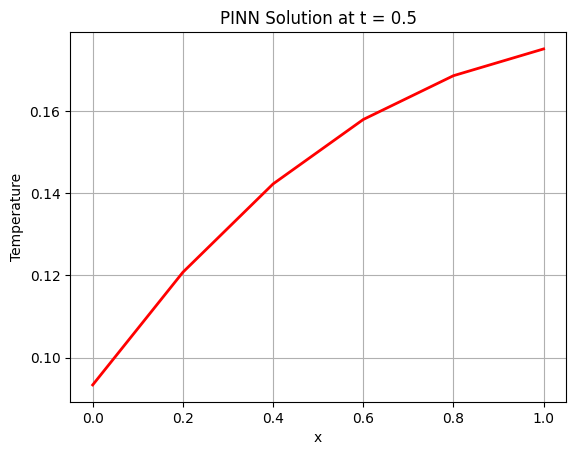

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

k = 0.958
final_time = 0.5

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 3),
            nn.Tanh(),

            nn.Linear(3, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


model = PINN()

# ==========================================================
# Optimizers
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # Interior points
    Nf = 20

    x = torch.rand(Nf,1,requires_grad=True)
    t = torch.rand(Nf,1,requires_grad=True)

    u = model(x,t)

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    loss_pde = ((u_t - k*u_xx)**2).mean()

    # Initial condition
    Ni = 6

    x0 = torch.rand(Ni,1)
    t0 = torch.zeros_like(x0)

    u0 = model(x0,t0)

    loss_ic = ((u0 - torch.sin(np.pi*x0))**2).mean()

    # Left boundary
    Nb = 6

    tb = torch.rand(Nb,1)

    xl = torch.zeros_like(tb)

    ul = model(xl,tb)

    loss_left = (ul**2).mean()

    # Right boundary

    xr = torch.ones_like(tb)

    ur = model(xr,tb)

    loss_right = (ur**2).mean()

    loss = (
        loss_pde
        + 10*loss_ic
        + 10*loss_left
        + 10*loss_right
    )

    return loss

# ==========================================================
# Adam Training
# ==========================================================

epochs = 500

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if epoch % 50 == 0:
        print(f"Epoch {epoch:5d}  Loss = {loss.item():.6e}")

# ==========================================================
# Prediction
# ==========================================================

x_test = torch.linspace(0,1,6).reshape(-1,1)
t_test = final_time*torch.ones_like(x_test)

with torch.no_grad():
    u_pred = model(x_test,t_test)

# ==========================================================
# Plot
# ==========================================================

plt.plot(x_test, u_pred, 'r', linewidth=2)
plt.xlabel("x")
plt.ylabel("Temperature")
plt.title(f"PINN Solution at t = {final_time}")
plt.grid(True)
plt.show()